In [11]:
# Standard library imports
import sys
import os

# Third-party imports
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# Setup path for src imports
notebooks_dir = os.path.dirname(os.path.abspath('__file__'))
root_dir = os.path.dirname(notebooks_dir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.training import train_xgboost
from src.evaluation import calculate_metrics
from src.visualisation import plot_actual_vs_predicted


# importing processed datasets for ML

X_train_stress = pd.read_csv("ml_ready_data/X_train_stress.csv")
X_test_stress = pd.read_csv("ml_ready_data/X_test_stress.csv")
y_train_stress = pd.read_csv("ml_ready_data/y_train_stress.csv").squeeze("columns")
y_test_stress = pd.read_csv("ml_ready_data/y_test_stress.csv").squeeze("columns")

X_train_deflection = pd.read_csv("ml_ready_data/X_train_deflection.csv")
X_test_deflection = pd.read_csv("ml_ready_data/X_test_deflection.csv")
y_train_deflection = pd.read_csv("ml_ready_data/y_train_deflection.csv").squeeze("columns")
y_test_deflection = pd.read_csv("ml_ready_data/y_test_deflection.csv").squeeze("columns")

print("Stress model     -> Train:", X_train_stress.shape, " Test:", X_test_stress.shape)
print("Deflection model -> Train:", X_train_deflection.shape, " Test:", X_test_deflection.shape)

Stress model     -> Train: (64, 6)  Test: (17, 6)
Deflection model -> Train: (64, 6)  Test: (17, 6)


In [12]:
# Importing important libraries

print('All libraries loaded...')

All libraries loaded...


# Stress Model

In [13]:
xgb_stress = train_xgboost(X_train_stress, y_train_stress)

pred_xgb_stress = xgb_stress.predict(X_test_stress) / 1e6  # Pa -> MPa
y_test_stress_mpa = y_test_stress / 1e6

metrics = calculate_metrics(y_test_stress, xgb_stress.predict(X_test_stress), unit_divisor=1e6)
print(f"XGB Stress -> MAE: {metrics['MAE']:.4f} MPa, RMSE: {metrics['RMSE']:.4f} MPa, R²: {metrics['R2']:.4f}")

XGB Stress -> MAE: 0.0719 MPa, RMSE: 0.0862 MPa, R²: 0.9999


# Deformation Model

In [14]:
xgb_deflection = train_xgboost(X_train_deflection, y_train_deflection)

pred_xgb_defl = xgb_deflection.predict(X_test_deflection) * 1000  # m -> mm
y_test_defl_mm = y_test_deflection * 1000

metrics = calculate_metrics(y_test_deflection, xgb_deflection.predict(X_test_deflection), unit_divisor=0.001)
print(f"XGB Deflection -> MAE: {metrics['MAE']:.4f} mm, RMSE: {metrics['RMSE']:.4f} mm, R²: {metrics['R2']:.4f}")

XGB Deflection -> MAE: 11.5119 mm, RMSE: 22.8623 mm, R²: 0.6097


# Plots

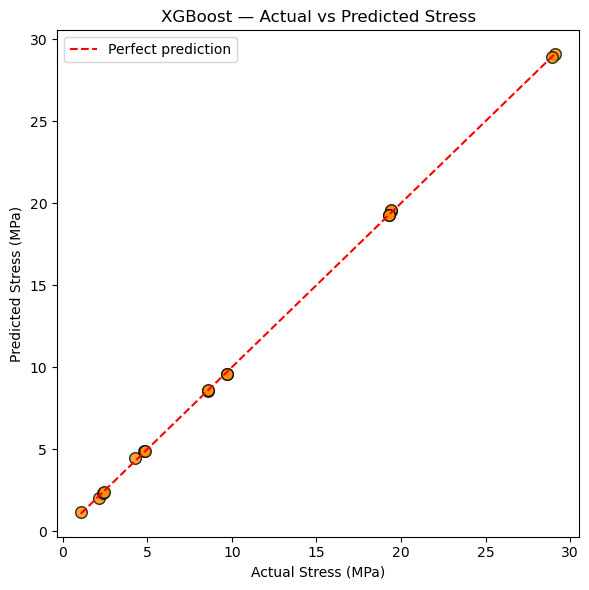

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_stress_mpa, pred_xgb_stress, s=70, alpha=0.8, edgecolor="k", color="darkorange")
lims = [min(y_test_stress_mpa.min(), pred_xgb_stress.min()), max(y_test_stress_mpa.max(), pred_xgb_stress.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual Stress (MPa)")
ax.set_ylabel("Predicted Stress (MPa)")
ax.set_title("XGBoost — Actual vs Predicted Stress")
ax.legend()
plt.tight_layout()
plt.show()

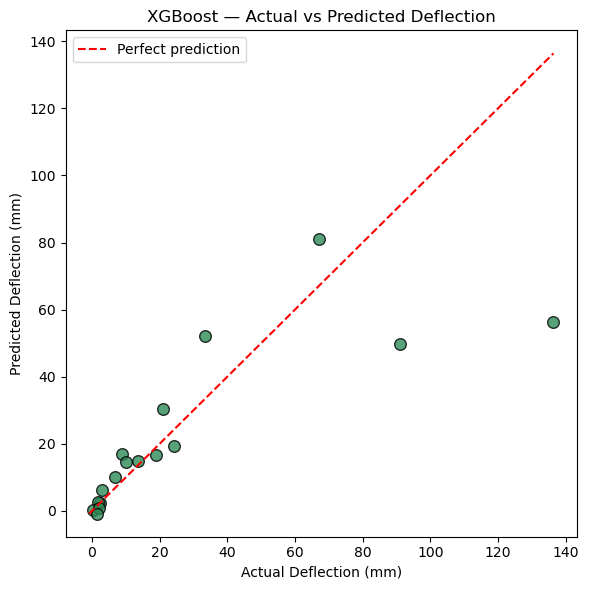

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_defl_mm, pred_xgb_defl, s=70, alpha=0.8, edgecolor="k", color="seagreen")
lims = [min(y_test_defl_mm.min(), pred_xgb_defl.min()), max(y_test_defl_mm.max(), pred_xgb_defl.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual Deflection (mm)")
ax.set_ylabel("Predicted Deflection (mm)")
ax.set_title("XGBoost — Actual vs Predicted Deflection")
ax.legend()
plt.tight_layout()
plt.show()